# Projet — Détection de faux profils

**Comment travailler :** exécute les cellules **dans l’ordre** (Menu *Run → Run All Above* si tu es perdu·e).

**Avant la 1ère fois :** dans un terminal à la racine du projet, lancer :
`python scripts/make_messy_dataset.py`

**Important :** ouvrir Jupyter **depuis la racine** du dossier `fakes-account`.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.paths import DATA_RAW, DATA_PROCESSED, MODELS_DIR
from src.data_loading import load_csv

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("OK — Racine projet :", ROOT)
print("Données brutes :", DATA_RAW)

OK — Racine projet : c:\Inge-2\Machine-learning\fake-profile-detector\fakes-account
Données brutes : C:\Inge-2\Machine-learning\fake-profile-detector\fakes-account\data\raw


## 1 — Charger les données (version « à nettoyer »)

Si une erreur apparaît, exécute d’abord `python scripts/make_messy_dataset.py` dans un terminal.

In [ ]:
import pandas as pd

df = pd.read_csv(r'C:\fake-profile-detector\fakes-account\data\raw\fake_social_media_messy.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   platform                  3035 non-null   object 
 1   has_profile_pic           2909 non-null   float64
 2   bio_length                2920 non-null   float64
 3   username_randomness       2913 non-null   float64
 4   followers                 2904 non-null   float64
 5   following                 2915 non-null   float64
 6   follower_following_ratio  2893 non-null   float64
 7   account_age_days          2922 non-null   float64
 8   posts                     2903 non-null   float64
 9   posts_per_day             2918 non-null   float64
 10  caption_similarity_score  2912 non-null   float64
 11  content_similarity_score  2923 non-null   float64
 12  follow_unfollow_rate      2907 non-null   float64
 13  spam_comments_rate        2944 non-null   float64
 14  generic_

### 1.1 type d'informations


In [10]:
df.dtypes

platform                     object
has_profile_pic             float64
bio_length                  float64
username_randomness         float64
followers                   float64
following                   float64
follower_following_ratio    float64
account_age_days            float64
posts                       float64
posts_per_day               float64
caption_similarity_score    float64
content_similarity_score    float64
follow_unfollow_rate        float64
spam_comments_rate          float64
generic_comment_rate        float64
suspicious_links_in_bio     float64
verified                    float64
is_fake                       int64
dtype: object

### 1.2 Valeurs manquantes et doublons

In [11]:
manquants = df.isna().sum()
print("Total NaN par colonne :")
print(manquants[manquants > 0])
print("\nTotal de cellules NaN :", df.isna().sum().sum())

dups = df.duplicated().sum()
print("\nLignes en double (toutes colonnes) :", dups)

Total NaN par colonne :
has_profile_pic             126
bio_length                  115
username_randomness         122
followers                   131
following                   120
follower_following_ratio    142
account_age_days            113
posts                       132
posts_per_day               117
caption_similarity_score    123
content_similarity_score    112
follow_unfollow_rate        128
spam_comments_rate           91
generic_comment_rate        114
suspicious_links_in_bio     125
verified                    131
dtype: int64

Total de cellules NaN : 1942

Lignes en double (toutes colonnes) : 6


### 1.3 Nettoyage de la base de données

In [15]:
from sklearn.preprocessing import LabelEncoder
df1=df.select_dtypes(include=['object']).isnull().sum()
df.astype(str).apply(lambda x: x.str.contains(r'^[^a-zA-Z0-9.]+$')).sum()

def categorical_features(df):
    object_columns = df.select_dtypes(include='object').columns
    label_encoder = LabelEncoder()
    for col in object_columns:
        df[col] = label_encoder.fit_transform(df[col])
    return df

df = categorical_features(df)


Split des features et de la base de donnée

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=df.drop('is_fake', axis=1)
y=df['is_fake']
scaler= StandardScaler()    #car on a une PCA et on utilise la variance par la suite
X_train,X_test,y_train,y_test = train_test_split(X, y,test_size=0.20, random_state=42)
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X)
print(y)

      platform  has_profile_pic  bio_length  username_randomness  followers  \
0            4              1.0       180.0                  1.0      431.0   
1            5              1.0       214.0                  0.0      426.0   
2            4              1.0        87.0                  0.0      426.0   
3            3              0.0        72.0                  0.0      385.0   
4            5              0.0       162.0                  1.0      392.0   
...        ...              ...         ...                  ...        ...   
3030         2              0.0       128.0                  1.0      395.0   
3031         4              1.0       243.0                  1.0      412.0   
3032         1              1.0       215.0                  1.0      372.0   
3033         2              1.0       204.0                  1.0      381.0   
3034         4              0.0       153.0                  1.0      435.0   

      following  follower_following_ratio  account_

### 1.4 Matrice de corrélation

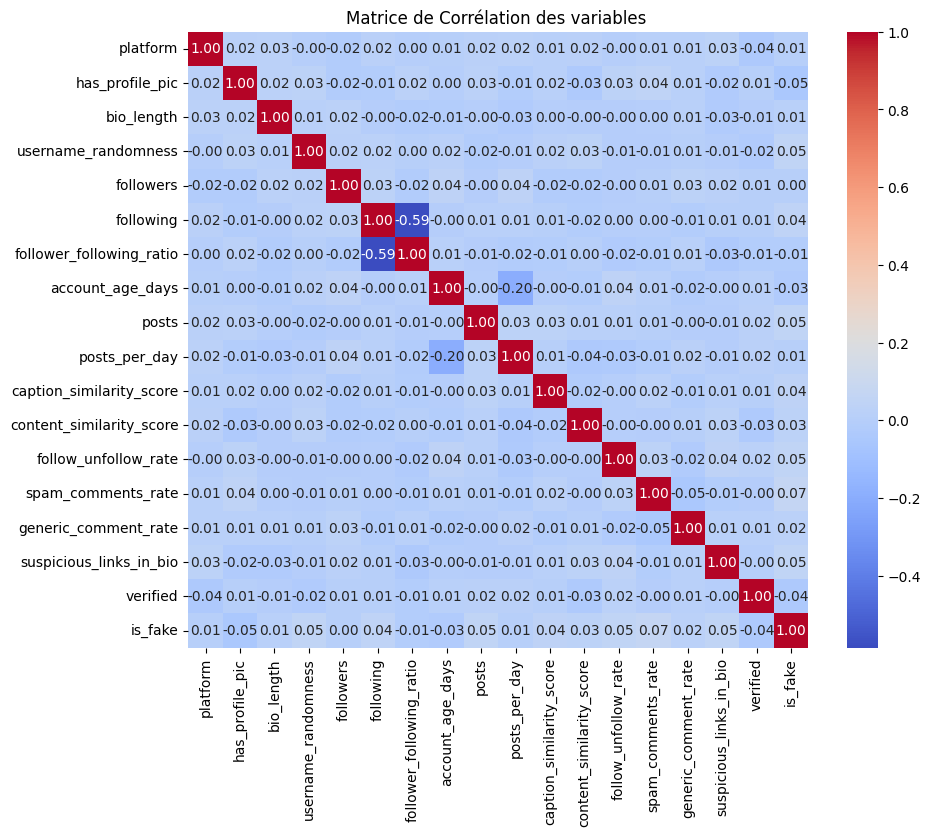

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des variables ")
plt.show()

---
Recherche des features importants

RMSE: 0.05
                          importance
content_similarity_score    0.231073
spam_comments_rate          0.121669
following                   0.116981
account_age_days            0.114661
caption_similarity_score    0.080622
posts                       0.075543
follow_unfollow_rate        0.060326
bio_length                  0.042503
generic_comment_rate        0.037877
followers                   0.031474
platform                    0.031108
posts_per_day               0.023543
follower_following_ratio    0.013246
username_randomness         0.006368
verified                    0.005849
suspicious_links_in_bio     0.005281
has_profile_pic             0.001878
<BarContainer object of 17 artists>


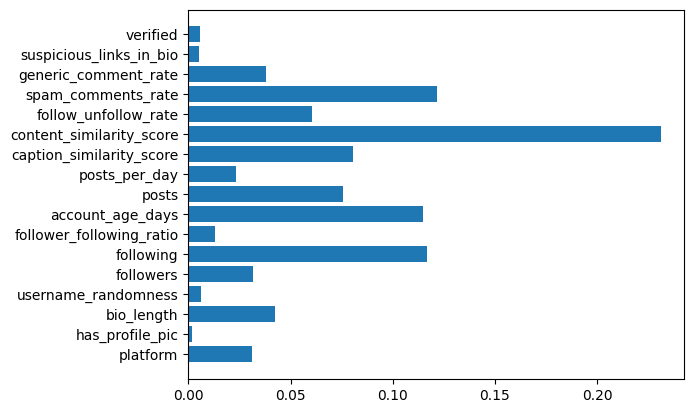

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error as MSE
rf1 = RandomForestRegressor(n_estimators=100)
rf1.fit(X_train, y_train)
y_pred = rf1.predict(X_test)
rmse_test = MSE(y_test, y_pred) ** (1/2)
print('RMSE: {:.2f}'.format(rmse_test))
featureimpor = pd.DataFrame(rf1.feature_importances_,index=X_train.columns,columns=["importance"]).sort_values("importance", ascending=False)
print(featureimpor)
print(plt.barh(X.columns,rf1.feature_importances_))

Suppression des features non important de la base

In [21]:
threshold = 0.002
cols_impor = featureimpor[featureimpor["importance"] > threshold].index
X = X[cols_impor]

print(X)

      content_similarity_score  spam_comments_rate  following  \
0                     0.243579                44.0      679.0   
1                     0.122000               196.0      729.0   
2                     0.835424               171.0      721.0   
3                          NaN                46.0      679.0   
4                     0.214862               184.0      709.0   
...                        ...                 ...        ...   
3030                  0.178557               189.0      703.0   
3031                  0.667181                57.0      664.0   
3032                  0.988089               192.0      660.0   
3033                  0.463280               110.0      691.0   
3034                  0.434313               146.0      672.0   

      account_age_days  caption_similarity_score  posts  follow_unfollow_rate  \
0                941.0                  0.699444  194.0                 456.0   
1               3164.0                  0.538005  202.0  

---
## 3 — Entraînement des modèles

**À faire ensuite :** `train_test_split` sur `df_model`, séparer `X` et `y` (`is_fake`), entraîner régression logistique, KNN, arbre, Random Forest, SVM, Naïve Bayes, sauvegarder avec `joblib` dans `models/`.

In [ ]:
# Exemple minimal (à étendre avec tous les modèles du sujet)
# from sklearn.model_selection import train_test_split
# X = df_model.drop(columns=["is_fake"])
# y = df_model["is_fake"]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# ...
print("Complète cette section une fois le nettoyage validé.")

## 4 — Évaluation et comparaison

**À faire :** `classification_report`, `confusion_matrix`, comparer les modèles pour le rapport et le frontend.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Exemple d’usage après y_pred :")
print(classification_report.__doc__.split("\n")[0])